In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [4]:
# Mạng nơ-ron dự báo cho 1 hàm phi tuyến 2 biến
X1 = np.linspace(-5, 5, 50)
X2 = np.linspace(-5, 5, 50)
print(X1.shape, X2.shape)

(50,) (50,)


In [ ]:
# Mô phỏng phương trình 2 biến theo X1, X2
# Y = 2X1^2 + 1.5X2^2 + 0.5X1X2 + 3X1 - 2X2 + 1

In [6]:
X1, X2 = np.meshgrid(X1, X2)
print(X1.shape, X2.shape)

(50, 50) (50, 50)


In [7]:
X1_flat = X1.flatten()
X2_flat = X2.flatten()
print(X1_flat.shape, X2_flat.shape)

(2500,) (2500,)


In [32]:
print(X1_flat[0], X1_flat[50], X1_flat[100])

-5.0 -5.0 -5.0


In [8]:
Y = 2*X1_flat**2 + 1.5*X2_flat**2 + 0.5*X1_flat*X2_flat + 3*X1_flat - 2*X2_flat + 1
Y = Y + np.random.normal(0, 2, len(Y))
print(Y.shape)

(2500,)


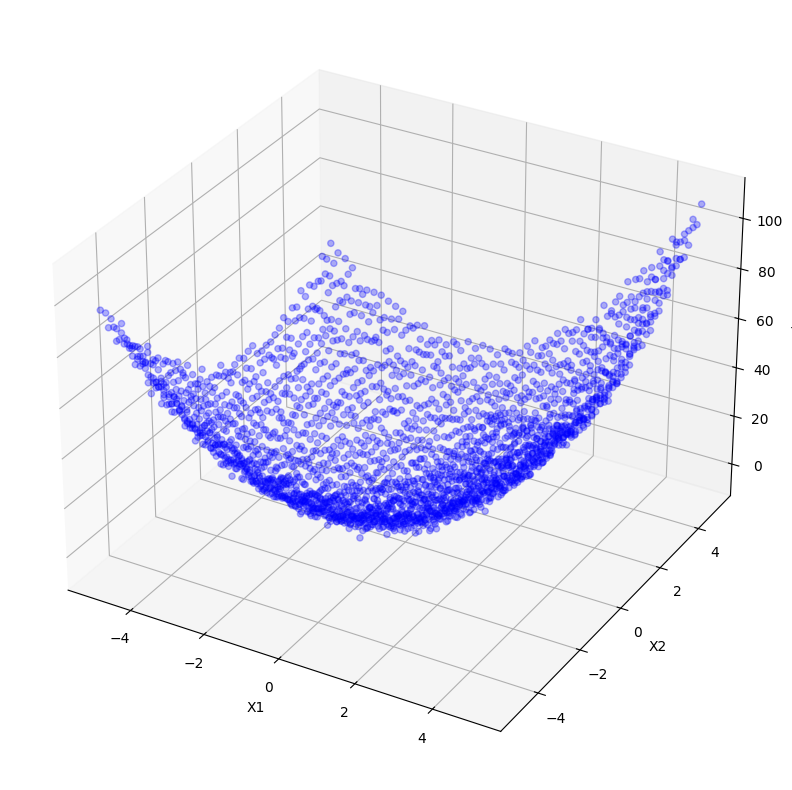

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1_flat, X2_flat, Y, c='blue', marker='o', alpha=0.3)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
plt.show()

In [10]:
# Sử dụng chuẩn hóa để giúp áp dụng các hàm kích hoạt tối ưu hơn => học nhanh hơn, đúng hơn
from sklearn.preprocessing import StandardScaler
x1_scaler = StandardScaler()
x2_scaler = StandardScaler()
y_scaler = StandardScaler()

X1_scaled = x1_scaler.fit_transform(X1_flat.reshape(-1, 1)).flatten()
X2_scaled = x2_scaler.fit_transform(X2_flat.reshape(-1, 1)).flatten()
Y_scaled = y_scaler.fit_transform(Y.reshape(-1, 1)).flatten()

print(X1_scaled.shape, X2_scaled.shape, Y_scaled.shape)

(2500,) (2500,) (2500,)


In [11]:
print(X1_flat[:5])
print(X1_scaled[:5])

[-5.         -4.79591837 -4.59183673 -4.3877551  -4.18367347]
[-1.69774938 -1.62845348 -1.55915759 -1.4898617  -1.4205658 ]


In [16]:
model = Sequential(
    [
        Dense(64, input_shape=(2,), activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation=None)
    ]
)
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
X_scaled = np.column_stack((X1_scaled, X2_scaled))
print(X_scaled.shape)

(2500, 2)


In [ ]:
# Input => Hidden layer 1
# Input: X_scaled => (2500, 2)
# Weights (2, 64)
# Bias (64, )
# Output (2500, 64)
# Z = f(XW + b)

# Hidden layer 1 => Hidden layer 2
# Input (2500, 64)
# Weights: (64, 32)
# Bias: (32, )
# Output: (2500, 32)

# Hidden layer 2 => Ouput
# Input: (2500, 32)
# Weights (32, 1)
# Ouput: (2500, 1)

In [ ]:
logs = model.fit(X_scaled, Y_scaled, epochs=50, verbose=1)

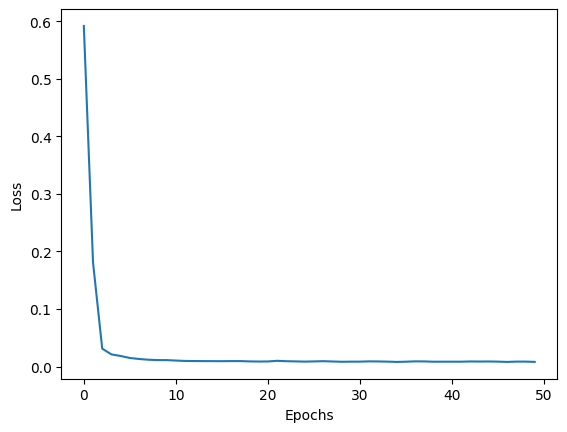

In [19]:
plt.plot(logs.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [20]:
Y_pred = model.predict(X_scaled)
print(Y_pred[:5])

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[2.7539246]
 [2.6072333]
 [2.4539254]
 [2.3064377]
 [2.164179 ]]


In [21]:
Y_pred = y_scaler.inverse_transform(Y_pred)
print(Y_pred[:5])

[[93.59267]
 [90.27399]
 [86.80561]
 [83.46892]
 [80.25052]]


In [27]:
print(Y_pred.shape)

(2500, 1)


In [28]:
Y_pred = Y_pred.flatten()
print(Y_pred.shape)

(2500,)


In [29]:
print(Y[:5])

[96.17780856 90.26122374 85.89213429 85.68417451 84.79404508]


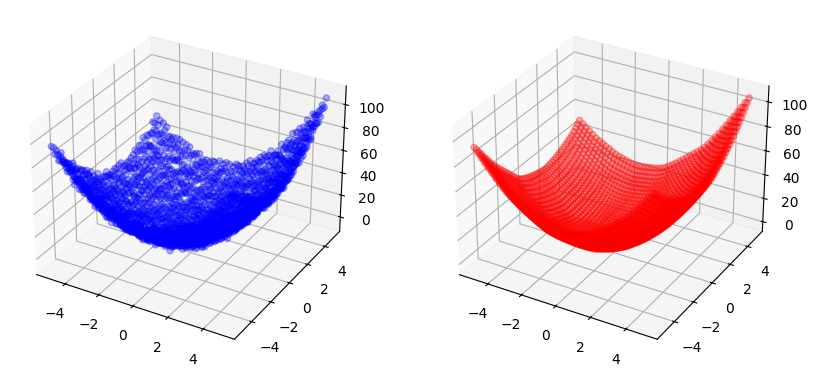

In [30]:
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X1_flat, X2_flat, Y, c='blue', marker='o', alpha=0.3)
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X1_flat, X2_flat, Y_pred, c='red', marker='o', alpha=0.3)

plt.show()

In [35]:
layer_0 = model.layers[0]
params = layer_0.get_weights()
weights = params[0]
bias = params[1]

print(weights.shape, bias.shape)

(2, 64) (64,)


In [37]:
print(weights[:5, :5])
print(bias[:5])

[[ 0.08878227 -0.02270808 -0.22380485  0.27489427  0.1013848 ]
 [ 0.16075113  0.01455588 -0.2363108   0.0763715   0.1834248 ]]
[-0.07835402  0.17449957 -0.12816422 -0.205917    0.01956479]
